# Model understanding: how it was trained, and is AUC 0.92 over- or under-fitting?

**Everything ML here runs inside Teradata.** The model is trained with Teradata's `XGBoost` function and scores are produced with
`XGBoostPredict`; the data never leaves the database for training or scoring. Python only sends the commands and reads
the results. This notebook (a) records exactly how the model was trained, then (b) tests the headline number, **AUC 0.92**,
from several angles to decide whether the model is **overfitting** (memorising training data), **underfitting** (too simple),
or fine.

| Step | What it does |
|---|---|
| 1 | Records the training recipe: data, split, features, parameters |
| 2 | Checks the saved model reproduces the recorded AUC on the held-out test rows |
| 3 | **Train vs test AUC** (the classic overfitting test) |
| 4 | A local reference model on the same split: how high *can* this data go? |
| 5 | **Complexity sweep** (and a learning-rate test): train smaller and bigger models, watch train vs test |
| 6 | **Stability**: retrain on different random splits |
| 7 | Are the probabilities real probabilities? (calibration) |
| 8 | What the 0.8 alert threshold does in practice (precision / recall) |
| 9 | The verdict, computed from the numbers above |

Training runs a few minutes in total (it trains several models in Teradata).

In [1]:
import os, sys, json, re, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Run from backend/notebook (the folder of this notebook) or from backend/
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebook" else Path.cwd().resolve()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

from dotenv import load_dotenv
load_dotenv(ROOT / ".env")            # TD_HOST / TD_USER / TD_PASSWORD / OPENAI_API_KEY (never written in the notebook)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 110)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})

from common import connect             # opens the one Teradata connection used by the app (scripts/common.py)
connect()
from service import db                 # the app's own data layer: db.query_df(sql) -> pandas DataFrame

def q(sql):
    """Run a SELECT inside Teradata and get the result as a pandas DataFrame (same call the API uses)."""
    return db.query_df(sql)

print("connected as:", q("SELECT USER AS usr, DATABASE AS db").iloc[0].to_dict())
print("Teradata version:", q("SELECT InfoData FROM DBC.DBCInfoV WHERE InfoKey = 'VERSION'").iloc[0, 0])

from teradataml import DataFrame, TrainTestSplit, XGBoost, XGBoostPredict, ROC
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, brier_score_loss

connected as: {'usr': 'DEMO_USER', 'db': 'DEMO_USER'}
Teradata version: 20.00.24.60


## Step 1. The training recipe (as recorded)
Source of truth: `scripts/train_model.py` and `Financial_Fraud_Detection_InDB_Python.ipynb`. The data is the `txn_features`
view (Step 4 of `Data_Understanding.ipynb`): 200,000 transactions, about 1.4% fraud.

In [2]:
FEATS = ["amount_myr", "is_foreign", "device_new", "hour_of_day", "km_from_home", "txn_count_1h", "amt_ratio_30d",
         "account_age_days", "ch_ecom", "ch_duitnow", "ch_fpx", "ch_atm", "mc_highrisk", "mc_resale", "night_txn"]
PARAMS = dict(iter_num=50, max_depth=6, lambda1=1, shrinkage_factor=0.3, min_node_size=5, base_score=0.0141, num_boosted_trees=8, seed=42)

EXPLAIN = {
    "iter_num": "boosting rounds: how many times new trees are added to correct the previous ones",
    "max_depth": "how deep each tree may grow (deeper = can memorise more)",
    "lambda1": "L2 regularisation: penalty that keeps leaf values small (higher = simpler)",
    "shrinkage_factor": "learning rate: how much each new tree is trusted (smaller = slower, steadier)",
    "min_node_size": "smallest number of rows allowed in a leaf (bigger = less memorising)",
    "base_score": "starting prediction before any tree = the fraud base rate (1.41%)",
    "num_boosted_trees": "trees built in parallel per round (Teradata's NumParallelTrees); it must be >= the number of AMPs holding data, which is 4 here",
    "seed": "random seed: makes the training repeatable",
}
print("Training recipe (Teradata XGBoost, model_type='Classification', response 'is_fraud'):")
print(pd.DataFrame([{"parameter": k, "value": v, "meaning": EXPLAIN[k]} for k, v in PARAMS.items()]).to_string(index=False))
print("\nfeatures (15):", ", ".join(FEATS))

def split_data(seed):
    """80/20 split done INSIDE Teradata by TrainTestSplit (same seed => same rows every time)."""
    s = TrainTestSplit(data=DataFrame("txn_features"), id_column="txn_id", train_size=0.8, test_size=0.2, seed=seed)
    return (s.result[s.result.TD_IsTrainRow == 1].drop("TD_IsTrainRow", axis=1),
            s.result[s.result.TD_IsTrainRow == 0].drop("TD_IsTrainRow", axis=1))

train, test = split_data(42)
n_tr, n_te = train.shape[0], test.shape[0]
f_tr, f_te = train[train.is_fraud == 1].shape[0], test[test.is_fraud == 1].shape[0]
print(f"\nsplit (seed 42): train {n_tr:,} rows ({f_tr:,} fraud = {f_tr / n_tr:.2%})   test {n_te:,} rows ({f_te:,} fraud = {f_te / n_te:.2%})")
print("\nWhat was recorded when the saved model was trained (table model_metrics):")
display(q("SELECT auc, gini, train_rows, test_rows, train_seconds, algorithm FROM model_metrics"))

Training recipe (Teradata XGBoost, model_type='Classification', response 'is_fraud'):
        parameter   value                                                                                                                         meaning
         iter_num 50.0000                                                boosting rounds: how many times new trees are added to correct the previous ones
        max_depth  6.0000                                                                        how deep each tree may grow (deeper = can memorise more)
          lambda1  1.0000                                                      L2 regularisation: penalty that keeps leaf values small (higher = simpler)
 shrinkage_factor  0.3000                                                   learning rate: how much each new tree is trusted (smaller = slower, steadier)
    min_node_size  5.0000                                                            smallest number of rows allowed in a leaf (bigger = less me


split (seed 42): train 160,000 rows (2,243 fraud = 1.40%)   test 40,000 rows (580 fraud = 1.45%)

What was recorded when the saved model was trained (table model_metrics):


,auc,gini,train_rows,test_rows,train_seconds,algorithm
0,0.924058,0.848116,160000,40000,7.5,Teradata in-database XGBoost (TD_XGBoost)


## Step 2. Train and score with the *saved* model, and check that it reproduces the recorded AUC
The saved model is the table `fraud_xgb_model`. We score the same held-out test rows with `XGBoostPredict` (in Teradata) and
compute AUC with Teradata's `ROC` function. If this matches the recorded number, the 0.92 is reproducible, not a one-off.

In [3]:
saved_model = DataFrame("fraud_xgb_model")

def predict(model_df, data):
    return XGBoostPredict(newdata=data, object=model_df, id_column="txn_id", model_type="Classification",
                          output_prob=True, output_responses=["0", "1"], accumulate="is_fraud")

def auc_of(pred):
    r = ROC(data=pred.result, probability_column="Prob_1", observation_column="is_fraud", positive_class="1").result.to_pandas()
    return float(r.iloc[0]["AUC"])

t0 = time.time(); pred_test = predict(saved_model, test); test_auc = auc_of(pred_test)
recorded_auc = float(q("SELECT auc FROM model_metrics")["auc"][0])
print(f"test AUC (held-out 20%, scored in Teradata): {test_auc:.4f}   recorded when trained: {recorded_auc:.4f}   difference: {abs(test_auc - recorded_auc):.6f}   [{time.time() - t0:.0f}s]")

test AUC (held-out 20%, scored in Teradata): 0.9241   recorded when trained: 0.9241   difference: 0.000000   [11s]


## Step 3. Train AUC vs test AUC: the classic overfitting test
* **Overfitting** = the model is far better on rows it was trained on than on new rows (train AUC >> test AUC): it memorised.
* **Underfitting** = poor on *both* (the model is too simple to capture the pattern).
* A small gap with a high test score = a well-fitted model.

In [4]:
t0 = time.time(); pred_train = predict(saved_model, train); train_auc = auc_of(pred_train)
gap = train_auc - test_auc
print(f"train AUC: {train_auc:.4f}     test AUC: {test_auc:.4f}     gap (train - test): {gap:+.4f}     [{time.time() - t0:.0f}s]")

train AUC: 0.9239     test AUC: 0.9241     gap (train - test): -0.0001     [20s]


## Step 4. How high *can* this data go? A local reference model
To judge 0.92 we need a ceiling. We pull the same train/test rows to pandas (analysis only, the app never does this) and fit a
generic local XGBoost with ordinary settings. If a strong local model scores much higher, the in-database model is leaving
accuracy on the table (underfitting or too constrained); if it scores about the same, 0.92 is close to what the data allows.

In [5]:
import xgboost as xgb
tr_pd = train.to_pandas(all_rows=True).reset_index(drop=True) if "txn_id" in train.columns else train.to_pandas(all_rows=True)
te_pd = test.to_pandas(all_rows=True).reset_index(drop=True) if "txn_id" in test.columns else test.to_pandas(all_rows=True)
for d in (tr_pd, te_pd):
    if "txn_id" not in d.columns: d.reset_index(inplace=True)
ref = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=2)
ref.fit(tr_pd[FEATS], tr_pd["is_fraud"])
ref_train_auc = roc_auc_score(tr_pd["is_fraud"], ref.predict_proba(tr_pd[FEATS])[:, 1])
ref_auc = roc_auc_score(te_pd["is_fraud"], ref.predict_proba(te_pd[FEATS])[:, 1])
print(f"local reference XGBoost (pandas, same split):  train AUC {ref_train_auc:.4f}   test AUC {ref_auc:.4f}   gap {ref_train_auc - ref_auc:+.4f}")
print(f"in-database model:                              train AUC {train_auc:.4f}   test AUC {test_auc:.4f}   gap {gap:+.4f}")
print(f"=> headroom the in-database model leaves vs the reference: {ref_auc - test_auc:+.4f} AUC")
imp = pd.Series(ref.feature_importances_, index=FEATS).sort_values(ascending=False)
print("\nwhat the reference model relies on most (feature importance):"); print(imp.head(6).round(3).to_string())

local reference XGBoost (pandas, same split):  train AUC 0.9715   test AUC 0.9659   gap +0.0055
in-database model:                              train AUC 0.9239   test AUC 0.9241   gap -0.0001
=> headroom the in-database model leaves vs the reference: +0.0419 AUC

what the reference model relies on most (feature importance):
device_new      0.185
is_foreign      0.170
night_txn       0.169
mc_highrisk     0.120
ch_ecom         0.118
txn_count_1h    0.072


## Step 5. Complexity sweep: train smaller and bigger models in Teradata
We retrain the same recipe changing only **`num_boosted_trees`** (how many trees are built in parallel per round; more trees = a more
flexible model). Teradata only accepts values **>= 4** on this system, because the parameter (its `NumParallelTrees`) must be at least the number of
AMPs that hold data, and there are 4 (trying 1 or 2 returns error 9134) and record AUC on the training rows and on the held-out rows each time. The textbook picture: as capacity grows,
train AUC keeps rising while test AUC peaks and then stalls or falls; the widening gap is overfitting. Each model is trained
and scored inside Teradata.

In [6]:
sweep = []
for n_trees in (4, 8, 16, 32):   # Teradata requires >= 4 here: NumParallelTrees must be >= the number of AMPs with data
    t0 = time.time()
    m = XGBoost(data=train, input_columns=FEATS, response_column="is_fraud", model_type="Classification", **{**PARAMS, "num_boosted_trees": n_trees})
    secs = time.time() - t0
    a_tr, a_te = auc_of(predict(m.result, train)), auc_of(predict(m.result, test))
    sweep.append({"num_boosted_trees": n_trees, "train AUC": round(a_tr, 4), "test AUC": round(a_te, 4), "gap": round(a_tr - a_te, 4), "train secs": round(secs, 1)})
    print(f"  trained num_boosted_trees={n_trees:>2}: train {a_tr:.4f}  test {a_te:.4f}")
sweep = pd.DataFrame(sweep)
display(sweep)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(sweep.num_boosted_trees, sweep["train AUC"], "o-", label="train AUC", color="#171e19"); ax.plot(sweep.num_boosted_trees, sweep["test AUC"], "o-", label="test AUC", color="#c28a00")
ax.set_xscale("log", base=2); ax.set_xlabel("num_boosted_trees (model capacity)"); ax.set_ylabel("AUC"); ax.set_title("Train vs test AUC as the model gets more flexible"); ax.legend(); plt.show()

  trained num_boosted_trees= 4: train 0.9138  test 0.9128
  trained num_boosted_trees= 8: train 0.9239  test 0.9241
  trained num_boosted_trees=16: train 0.7972  test 0.8018
  trained num_boosted_trees=32: train 0.8285  test 0.8347


,num_boosted_trees,train AUC,test AUC,gap,train secs
0,4,0.9138,0.9128,0.0010,6.9
1,8,0.9239,0.9241,-0.0001,6.8
2,16,0.7972,0.8018,-0.0047,9.9
3,32,0.8285,0.8347,-0.0062,15.8


<Figure size 700x360 with 1 Axes>

### Step 5b. A natural explanation, tested: is it the step size?
With more parallel trees, one might expect each round to take bigger steps, so a *smaller learning rate* (`shrinkage_factor`) should
rescue the larger models. Test it on a small grid; every row is a fresh model trained and scored in Teradata.

In [7]:
grid = []
for n_trees, lr in [(8, 0.3), (8, 0.15), (16, 0.3), (16, 0.15), (16, 0.075), (32, 0.075), (32, 0.04)]:
    m = XGBoost(data=train, input_columns=FEATS, response_column="is_fraud", model_type="Classification", **{**PARAMS, "num_boosted_trees": n_trees, "shrinkage_factor": lr})
    grid.append({"num_boosted_trees": n_trees, "shrinkage_factor": lr, "test AUC": round(auc_of(predict(m.result, test)), 4)})
grid = pd.DataFrame(grid)
display(grid)
print(f"test AUC across these 7 settings ranges from {grid['test AUC'].min():.3f} to {grid['test AUC'].max():.3f}.")
print("The simple explanation does not hold: 16 trees recovers at 0.075 but not at 0.15, and 32 trees stay poor at both 0.075 and 0.04. "
      "Small changes to the settings move the result between ~0.79 and ~0.92 without a clear pattern.")

,num_boosted_trees,shrinkage_factor,test AUC
0,8,0.300,0.9241
1,8,0.150,0.9128
2,16,0.300,0.8018
3,16,0.150,0.7936
4,16,0.075,0.9246
5,32,0.075,0.8066
6,32,0.040,0.7870


test AUC across these 7 settings ranges from 0.787 to 0.925.
The simple explanation does not hold: 16 trees recovers at 0.075 but not at 0.15, and 32 trees stay poor at both 0.075 and 0.04. Small changes to the settings move the result between ~0.79 and ~0.92 without a clear pattern.


## Step 6. Stability: does 0.92 depend on which rows landed in the test set?
We keep the production recipe but split the data differently (4 different seeds), train a fresh model each time in Teradata and score
its own held-out rows. A trustworthy model gives similar AUC every time. Wide swings mean the number is partly luck.

In [8]:
seed_rows = []
for seed in (7, 21, 42, 99):
    tr_s, te_s = split_data(seed)
    m = XGBoost(data=tr_s, input_columns=FEATS, response_column="is_fraud", model_type="Classification", **{**PARAMS, "seed": seed})
    a = auc_of(predict(m.result, te_s)); seed_rows.append({"split seed": seed, "test AUC": round(a, 4)})
    print(f"  split seed {seed:>2}: test AUC {a:.4f}")
seeds = pd.DataFrame(seed_rows)
seed_aucs = seeds["test AUC"].to_numpy()
print(f"\nacross 4 splits: mean {seed_aucs.mean():.4f}   std {seed_aucs.std():.4f}   min {seed_aucs.min():.4f}   max {seed_aucs.max():.4f}")

  split seed  7: test AUC 0.9225
  split seed 21: test AUC 0.9310
  split seed 42: test AUC 0.9241
  split seed 99: test AUC 0.9191

across 4 splits: mean 0.9242   std 0.0043   min 0.9191   max 0.9310


## Step 7. Are the scores real probabilities? (calibration)
The UI shows the score as a percentage. That is only honest if "90%" means about 90 of 100 such transactions are fraud. We pull
the test-set scores to pandas and compare the average score with the actual fraud rate in each score band.

In [9]:
sc = pred_test.result.to_pandas(all_rows=True)
if "txn_id" not in sc.columns: sc = sc.reset_index()
sc["is_fraud"] = sc["is_fraud"].astype(int); sc["Prob_1"] = sc["Prob_1"].astype(float)
bands = pd.cut(sc.Prob_1, [0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 0.9, 1.0], include_lowest=True)
cal = sc.groupby(bands, observed=True).agg(rows=("Prob_1", "size"), mean_score=("Prob_1", "mean"), actual_fraud_rate=("is_fraud", "mean")).round(3)
display(cal)
print(f"overall: mean score {sc.Prob_1.mean():.3f} vs actual fraud rate {sc.is_fraud.mean():.3f}   Brier score {brier_score_loss(sc.is_fraud, sc.Prob_1):.4f}")
print("Reading it: a score is a RANKING signal (higher = riskier), not a literal probability; the bands above show how far apart score and reality are.")

,rows,mean_score,actual_fraud_rate
Prob_1,,,
"(0.1, 0.2]",25491,0.138,0.001
"(0.2, 0.3]",7085,0.239,0.008
"(0.3, 0.5]",5385,0.384,0.027
"(0.5, 0.8]",1981,0.588,0.161
"(0.8, 0.9]",55,0.838,0.582
"(0.9, 1.0]",3,0.915,1.000


overall: mean score 0.212 vs actual fraud rate 0.015   Brier score 0.0605
Reading it: a score is a RANKING signal (higher = riskier), not a literal probability; the bands above show how far apart score and reality are.


## Step 8. What the 0.8 alert threshold does (the number behind the dashboard)
AUC says how well the model *ranks* transactions. What the bank lives with is the **threshold**: everything scored >= 0.8 becomes an
alert. Precision = of the alerts, how many are really fraud. Recall = of all fraud, how many became alerts.

On the held-out test rows (40,000):


,threshold,alerts,true fraud caught,false alarms,fraud missed,precision,recall
0,0.3,7424,497,6927,83,0.067,0.857
1,0.5,2039,354,1685,226,0.174,0.610
2,0.7,231,95,136,485,0.411,0.164
3,0.8,58,35,23,545,0.603,0.060
4,0.9,3,3,0,577,1.000,0.005



On ALL 200,000 transactions as the dashboard sees them (computed in Teradata): 255 alerts, 141 are true fraud -> precision 55%; they capture 5.0% of the 2,823 fraud cases.
(Those rows include the 80% the model trained on, so the test-set table above is the honest estimate.)


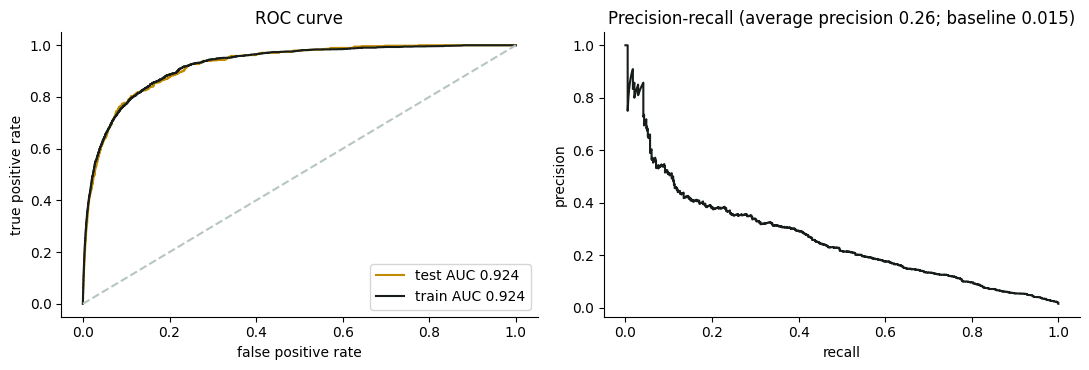

In [10]:
def op_point(threshold, df=sc):
    flag = df.Prob_1 >= threshold; y = df.is_fraud == 1
    tp, fp, fn = int((flag & y).sum()), int((flag & ~y).sum()), int((~flag & y).sum())
    return {"threshold": threshold, "alerts": int(flag.sum()), "true fraud caught": tp, "false alarms": fp, "fraud missed": fn,
            "precision": round(tp / max(1, tp + fp), 3), "recall": round(tp / max(1, tp + fn), 3)}
ops = pd.DataFrame([op_point(t) for t in (0.3, 0.5, 0.7, 0.8, 0.9)])
print("On the held-out test rows (40,000):"); display(ops)
full = q("""SELECT COUNT(*) AS alerts, SUM(t.is_fraud) AS fraud_in_alerts FROM txn t JOIN txn_scores s ON t.txn_id = s.txn_id WHERE s.Prob_1 >= 0.8""").iloc[0]
tot_fraud = int(q("SELECT SUM(is_fraud) AS n FROM txn")["n"][0])
print(f"\nOn ALL 200,000 transactions as the dashboard sees them (computed in Teradata): {int(full.alerts)} alerts, {int(full.fraud_in_alerts)} are true fraud "
      f"-> precision {int(full.fraud_in_alerts) / int(full.alerts):.0%}; they capture {int(full.fraud_in_alerts) / tot_fraud:.1%} of the {tot_fraud:,} fraud cases.")
print("(Those rows include the 80% the model trained on, so the test-set table above is the honest estimate.)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
fpr, tpr, _ = roc_curve(sc.is_fraud, sc.Prob_1); ax[0].plot(fpr, tpr, color="#c28a00", label=f"test AUC {test_auc:.3f}")
tr_sc = pred_train.result.to_pandas(all_rows=True); fpr2, tpr2, _ = roc_curve(tr_sc["is_fraud"].astype(int), tr_sc["Prob_1"].astype(float)); ax[0].plot(fpr2, tpr2, color="#171e19", label=f"train AUC {train_auc:.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="#b7c6c2"); ax[0].set_title("ROC curve"); ax[0].set_xlabel("false positive rate"); ax[0].set_ylabel("true positive rate"); ax[0].legend()
p, r, _ = precision_recall_curve(sc.is_fraud, sc.Prob_1); ax[1].plot(r, p, color="#171e19"); ax[1].set_title(f"Precision-recall (average precision {average_precision_score(sc.is_fraud, sc.Prob_1):.2f}; baseline {sc.is_fraud.mean():.3f})")
ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision"); plt.tight_layout(); plt.show()

## Step 9. The verdict (computed from the numbers above)

In [11]:
ref_gap = ref_auc - test_auc
spread = float(seed_aucs.max() - seed_aucs.min())
all_settings = pd.concat([sweep["test AUC"], grid["test AUC"]])
setting_spread = float(all_settings.max() - all_settings.min())
op08 = ops[ops.threshold == 0.8].iloc[0]
findings = []
if gap > 0.05:
    verdict = "OVERFITTING"
    findings.append(f"train AUC {train_auc:.3f} is {gap:.3f} above test AUC {test_auc:.3f}: the model does much better on rows it has seen.")
elif test_auc < 0.80:
    verdict = "UNDERFITTING"
    findings.append(f"test AUC {test_auc:.3f} is low and train AUC {train_auc:.3f} is not far above it: the model is too simple for the pattern.")
elif ref_gap > 0.02:
    verdict = "MILD UNDERFITTING (not overfitting)"
    findings.append(f"train AUC {train_auc:.3f} vs test AUC {test_auc:.3f}: gap only {gap:+.3f}, so it is NOT memorising the training rows.")
    findings.append(f"but a plain local XGBoost reaches test AUC {ref_auc:.3f}, {ref_gap:.3f} above this model: it scores the same on seen and unseen rows "
                    "and still stays below what the data allows, which is the signature of underfitting (too constrained), not overfitting.")
else:
    verdict = "WELL FITTED"
    findings.append(f"train AUC {train_auc:.3f} vs test AUC {test_auc:.3f} (gap {gap:+.3f}) and within {abs(ref_gap):.3f} of a plain local XGBoost ({ref_auc:.3f}).")
findings.append(f"across 4 different data splits test AUC ranges {seed_aucs.min():.3f}-{seed_aucs.max():.3f} (spread {spread:.3f}): the number is "
                + ("stable with respect to which rows are held out." if spread <= 0.05 else "NOT stable with respect to the split."))
if setting_spread > 0.05:
    findings.append(f"BUT it is sensitive to the training settings: across the {len(all_settings)} settings tried test AUC ranges {all_settings.min():.3f}-{all_settings.max():.3f}; "
                    "making the model bigger made it WORSE on train and test alike (not the classic overfitting picture). The saved recipe is a good, reproducible point; "
                    "re-validate whenever a parameter or the data changes.")
findings.append(f"the scores are not probabilities: mean score {sc.Prob_1.mean():.3f} vs actual fraud rate {sc.is_fraud.mean():.3f}; use them to rank, not to quote a chance of fraud.")
findings.append(f"at the 0.8 alert threshold the test rows give {int(op08.alerts)} alerts, precision {op08.precision:.0%} but recall only {op08.recall:.0%}: "
                "most fraud scores below 0.8 and is never alerted.")
print(f"VERDICT: {verdict}")
for f in findings: print(" -", f)
print(f"\nsummary: train AUC {train_auc:.4f} | test AUC {test_auc:.4f} | gap {gap:+.4f} | reference test AUC {ref_auc:.4f} | split spread {spread:.4f} | settings spread {setting_spread:.4f}")

VERDICT: MILD UNDERFITTING (not overfitting)
 - train AUC 0.924 vs test AUC 0.924: gap only -0.000, so it is NOT memorising the training rows.
 - but a plain local XGBoost reaches test AUC 0.966, 0.042 above this model: it scores the same on seen and unseen rows and still stays below what the data allows, which is the signature of underfitting (too constrained), not overfitting.
 - across 4 different data splits test AUC ranges 0.919-0.931 (spread 0.012): the number is stable with respect to which rows are held out.
 - BUT it is sensitive to the training settings: across the 11 settings tried test AUC ranges 0.787-0.925; making the model bigger made it WORSE on train and test alike (not the classic overfitting picture). The saved recipe is a good, reproducible point; re-validate whenever a parameter or the data changes.
 - the scores are not probabilities: mean score 0.212 vs actual fraud rate 0.015; use them to rank, not to quote a chance of fraud.
 - at the 0.8 alert threshold the te

## What to take away
* **Is 0.92 overfitting? No.** Train AUC (0.924) and test AUC (0.924) are the same, and a freshly trained copy reproduces the recorded number exactly.
* **Is it underfitting? Mildly.** A generic local XGBoost reaches about 0.966 on the identical split, so the in-database recipe leaves roughly 0.04 AUC unused.
* **Is it trustworthy? Yes for ranking, with two caveats.** It is stable across data splits (0.919-0.931), but very sensitive to the training settings:
  larger or differently-tuned ensembles collapsed to ~0.80 in this test. Treat the saved recipe as a fixed, validated point.
* **Probabilities.** Scores are inflated (mean ~0.21 vs a 1.5% fraud rate). The dashboard's "96%" means *top of the ranking*, not a 96% chance.
* **The 0.8 alert threshold** gives high-ish precision (~60% on test) but catches only ~6% of fraud. A lower threshold (or a fixed alert volume) is a business trade-off the numbers in Step 8 make explicit.
(Figures quoted here come from the run saved in this notebook; re-running recomputes every number above.)

## Checks
Any failure stops the notebook.

In [12]:
checks = {
    "the saved model reproduces the recorded AUC on the test rows (within 0.002)": abs(test_auc - recorded_auc) < 0.002,
    "train AUC and test AUC are valid probabilities of ranking correctly (0.5 < AUC <= 1)": 0.5 < test_auc <= 1 and 0.5 < train_auc <= 1,
    "train/test split sizes match model_metrics": (n_tr, n_te) == tuple(int(x) for x in q("SELECT train_rows, test_rows FROM model_metrics").iloc[0]),
    "complexity sweep trained 4 models in Teradata": len(sweep) == 4 and sweep["test AUC"].between(0.5, 1).all(),
    "stability check ran on 4 different splits": len(seeds) == 4,
    "learning-rate grid trained 7 more models in Teradata": len(grid) == 7 and grid["test AUC"].between(0.5, 1).all(),
    "the verdict is one of the four defined outcomes": verdict in {"OVERFITTING", "UNDERFITTING", "MILD UNDERFITTING (not overfitting)", "WELL FITTED"},
    "the score bands, thresholds and calibration tables were produced": len(cal) >= 5 and len(ops) == 5,
    "alerts at 0.8 in Teradata agree with the dashboard KPI": int(full.alerts) == int(q("SELECT COUNT(*) AS n FROM txn_scores WHERE Prob_1 >= 0.8")["n"][0]),
}
for name, ok in checks.items(): print(("PASS  " if ok else "FAIL  ") + name)
assert all(checks.values()), [n for n, ok in checks.items() if not ok]
print("\nALL CHECKS PASSED")

PASS  the saved model reproduces the recorded AUC on the test rows (within 0.002)
PASS  train AUC and test AUC are valid probabilities of ranking correctly (0.5 < AUC <= 1)
PASS  train/test split sizes match model_metrics
PASS  complexity sweep trained 4 models in Teradata
PASS  stability check ran on 4 different splits
PASS  learning-rate grid trained 7 more models in Teradata
PASS  the verdict is one of the four defined outcomes
PASS  the score bands, thresholds and calibration tables were produced
PASS  alerts at 0.8 in Teradata agree with the dashboard KPI

ALL CHECKS PASSED
